# RAMAN Analysis Notebook

Manual path-based workflow: convert a Raman TXT map to NPZ, preprocess and save the hypercube, then plot maps and spectra with matplotlib.

In [ ]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import preprocess as pp
import ploting_tool as ppm
from utils import *


## 1. Manual input and output paths

In [2]:
# TXT -> NPZ conversion paths. Leave TXT_INPUT_PATH empty to skip conversion.
TXT_INPUT_PATH = r"CZTS_31_249606_290526_532nm_10%_10s_2a_s_map1700x1700_no_edge.txt"
TXT_OUTPUT_NPZ = r"parsed_spectra_551_points/raman_hypercube_manual.npz"

# Input for preprocessing. If the conversion cell runs, it updates RAW_NPZ_PATH to TXT_OUTPUT_NPZ.
RAW_NPZ_PATH = TXT_OUTPUT_NPZ
PROCESSED_OUTPUT_NPZ = r"parsed_spectra_551_points/raman_hypercube_manual_processed.npz"

# Plot output paths. Set to None if you only want to display the figure.
PEAK_MAP_OUTPUT_PNG = r"peak_map_manual.png"
SPECTRUM_OUTPUT_PNG = r"spectrum_manual.png"


## 2. Convert TXT file to NPZ

In [9]:
# Simple conversion options.
CONVERT_NAN_TO_ZERO = True
NORMALIZE_BY_GLOBAL_MAX = False
NORMALIZE_BY_PEAK = False
NORMALIZE_PEAK_CM = 338.0
NORMALIZE_PEAK_WIDTH_CM = 5.0

txt_input = Path(TXT_INPUT_PATH)
txt_output_npz = Path(TXT_OUTPUT_NPZ)

if str(TXT_INPUT_PATH).strip():
    if not txt_input.exists():
        raise FileNotFoundError(txt_input)

    df = parse_map_file(txt_input)
    x, y, wave, intensity = build_hypercube(df)

    if CONVERT_NAN_TO_ZERO:
        intensity = replace_nan_with_zero(intensity)

    if NORMALIZE_BY_GLOBAL_MAX and NORMALIZE_BY_PEAK:
        raise ValueError("Choose only one normalization option.")
    if NORMALIZE_BY_GLOBAL_MAX:
        intensity, reference_value = normalize_intensity_cube(intensity)
        print(f"Normalized by global max: {reference_value:.6g}")
    if NORMALIZE_BY_PEAK:
        intensity, reference_value = normalize_intensity_cube_by_peak_window(
            intensity,
            wave,
            target_peak=NORMALIZE_PEAK_CM,
            window_width=NORMALIZE_PEAK_WIDTH_CM,
        )
        print(f"Normalized by peak window: {reference_value:.6g}")

    txt_output_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(txt_output_npz, x=x, y=y, wave=wave, intensity=intensity)
    RAW_NPZ_PATH = str(txt_output_npz)

    print(f"Saved NPZ: {txt_output_npz}")
    print(f"Hypercube shape: {intensity.shape}")
    print(f"Wave range: {wave[0]:.1f} to {wave[-1]:.1f} cm^-1")
else:
    print("TXT_INPUT_PATH is empty; skipping TXT -> NPZ conversion.")


Saved NPZ: parsed_spectra_551_points\raman_hypercube_manual.npz
Hypercube shape: (27, 27, 1015)
Wave range: -477.0 to 1408.0 cm^-1


## 3. Preprocessing arguments

In [10]:
# Switch preprocessing steps on/off with True or False.
APPLY_BASELINE_ALS = True
APPLY_BASELINE_SNIP = False
REMOVE_COSMIC_RAYS = True
APPLY_DENOISE_SAVGOL = True
APPLY_DENOISE_GAUSSIAN = False
APPLY_SPECTRAL_CROP = True

# Parameters used only when the matching option above is True.
BASELINE_ALS_LAM = 1e4
BASELINE_ALS_P = 0.01
BASELINE_SNIP_ITERATIONS = 20
COSMIC_RAY_THRESHOLD = 3.0
SAVGOL_WINDOW_LENGTH = 5
SAVGOL_POLYORDER = 2
GAUSSIAN_SIGMA = 1.0
CROP_MIN_CM = 150.0
CROP_MAX_CM = 800.0


## 4. Process hypercube and save NPZ

In [11]:
def preprocess_hypercube(input_npz_path, output_npz_path):
    input_npz_path = Path(input_npz_path)
    output_npz_path = Path(output_npz_path)

    if not input_npz_path.exists():
        raise FileNotFoundError(input_npz_path)
    if APPLY_BASELINE_ALS and APPLY_BASELINE_SNIP:
        raise ValueError("Choose only one baseline correction option.")
    if APPLY_DENOISE_SAVGOL and APPLY_DENOISE_GAUSSIAN:
        raise ValueError("Choose only one denoise option.")

    x, y, wave, intensity = pp.load_hypercube(input_npz_path)
    print(f"Loaded: {input_npz_path}")
    print(f"Input shape: {intensity.shape}")

    if APPLY_BASELINE_ALS:
        intensity = pp.baseline_correct_als(intensity, lam=BASELINE_ALS_LAM, p=BASELINE_ALS_P)
    if APPLY_BASELINE_SNIP:
        intensity = pp.baseline_correct_snip(intensity, niter=BASELINE_SNIP_ITERATIONS)
    if REMOVE_COSMIC_RAYS:
        intensity = pp.remove_cosmic_rays(intensity, threshold=COSMIC_RAY_THRESHOLD)
    if APPLY_DENOISE_SAVGOL:
        intensity = pp.denoise_savgol(
            intensity,
            window_length=SAVGOL_WINDOW_LENGTH,
            polyorder=SAVGOL_POLYORDER,
        )
    if APPLY_DENOISE_GAUSSIAN:
        intensity = pp.denoise_gaussian(intensity, sigma=GAUSSIAN_SIGMA)
    if APPLY_SPECTRAL_CROP:
        intensity, wave = pp.spectral_crop(intensity, wave, CROP_MIN_CM, CROP_MAX_CM)

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    pp.save_hypercube(output_npz_path, x, y, wave, intensity)
    print(f"Saved processed NPZ: {output_npz_path}")
    print(f"Output shape: {intensity.shape}")
    return x, y, wave, intensity


x, y, wave, processed_intensity = preprocess_hypercube(RAW_NPZ_PATH, PROCESSED_OUTPUT_NPZ)


Loaded: parsed_spectra_551_points\raman_hypercube_manual.npz
Input shape: (27, 27, 1015)
  Applying ALS baseline correction to the hypercube...
    Processed 2/27 rows
    Processed 4/27 rows
    Processed 6/27 rows
    Processed 8/27 rows
    Processed 10/27 rows
    Processed 12/27 rows
    Processed 14/27 rows
    Processed 16/27 rows
    Processed 18/27 rows
    Processed 20/27 rows
    Processed 22/27 rows
    Processed 24/27 rows
    Processed 26/27 rows
  Removing cosmic rays...
    Processed 2/27 rows
    Processed 4/27 rows
    Processed 6/27 rows


c:\Users\parch602\OneDrive - Uppsala universitet\Uppsala_postdoc_work\RAMAN\RAMAN-analysis\.venv\Lib\site-packages\ramanspy\preprocessing\despike.py:63: RuntimeWarning: invalid value encountered in divide
  modified_z_scores = np.array(0.6745 * (spectrum - np.median(spectrum)) / mad_term)


    Processed 8/27 rows
    Processed 10/27 rows
    Processed 12/27 rows
    Processed 14/27 rows
    Processed 16/27 rows
    Processed 18/27 rows
    Processed 20/27 rows
    Processed 22/27 rows
    Processed 24/27 rows
    Processed 26/27 rows
  Applying Savitzky-Golay denoising...
    Processed 2/27 rows
    Processed 4/27 rows
    Processed 6/27 rows
    Processed 8/27 rows
    Processed 10/27 rows
    Processed 12/27 rows
    Processed 14/27 rows
    Processed 16/27 rows
    Processed 18/27 rows
    Processed 20/27 rows
    Processed 22/27 rows
    Processed 24/27 rows
    Processed 26/27 rows
  Cropping spectral range to 150.0-800.0 cm^-1...
Saved processed NPZ: parsed_spectra_551_points\raman_hypercube_manual_processed.npz
Output shape: (27, 27, 349)


## 5. Plot with matplotlib

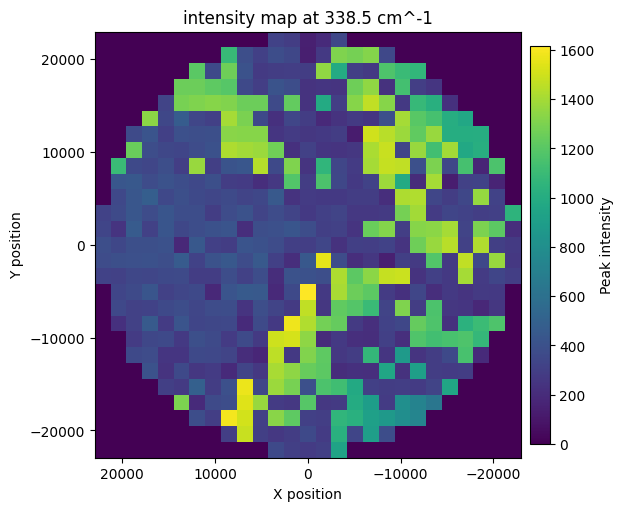

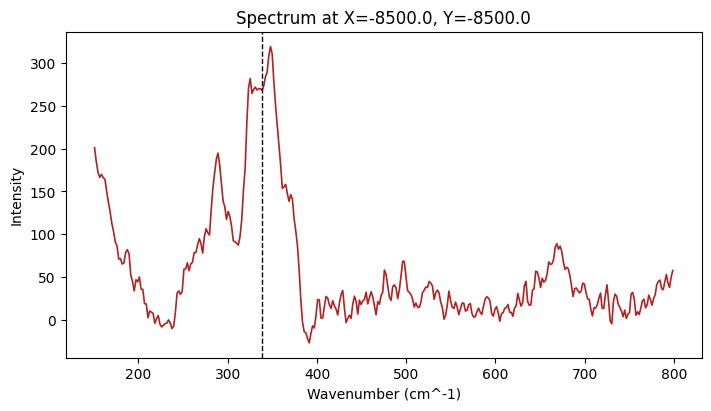

Saved peak map: peak_map_manual.png
Saved spectrum: spectrum_manual.png


In [14]:
# Manual plotting options.
PLOT_INPUT_NPZ = PROCESSED_OUTPUT_NPZ
TARGET_PEAK_CM = 338
SEARCH_WIDTH_POINTS = 5
MAP_TYPE = "intensity"  # "intensity" or "peak-to-base-ratio"
SMOOTH_MAP_SIGMA = 0.0
SELECTED_X_INDEX = 8      
SELECTED_Y_INDEX = 8

plot_input_npz = Path(PLOT_INPUT_NPZ)
x, y, wave, intensity = pp.load_hypercube(plot_input_npz)

if MAP_TYPE == "intensity":
    peak_map, matched_wave, lo, hi = ppm.compute_peak_map(
        wave, intensity, TARGET_PEAK_CM, SEARCH_WIDTH_POINTS
    )
    colorbar_label = "Peak intensity"
elif MAP_TYPE == "peak-to-base-ratio":
    peak_map, matched_wave, lo, hi = ppm.compute_peak_to_base_ratio_map(
        wave, intensity, TARGET_PEAK_CM, SEARCH_WIDTH_POINTS
    )
    colorbar_label = "Peak/base ratio"
else:
    raise ValueError('MAP_TYPE must be "intensity" or "peak-to-base-ratio".')

if SMOOTH_MAP_SIGMA > 0:
    peak_map = ppm.smooth_map(peak_map, SMOOTH_MAP_SIGMA)

map_title = f"{MAP_TYPE} map at {matched_wave:.1f} cm^-1"
fig, ax = ppm.plot_peak_map(
    x,
    y,
    peak_map,
    title=map_title,
    output_path=PEAK_MAP_OUTPUT_PNG,
    colorbar_label=colorbar_label,
)
plt.show()

xi = int(np.clip(SELECTED_X_INDEX, 0, len(x) - 1))
yi = int(np.clip(SELECTED_Y_INDEX, 0, len(y) - 1))
spectrum = np.nan_to_num(intensity[xi, yi, :], nan=0.0)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(wave, spectrum, color="firebrick", linewidth=1.2)
ax.axvline(matched_wave, color="black", linestyle="--", linewidth=1.0)
ax.set_title(f"Spectrum at X={x[xi]}, Y={y[yi]}")
ax.set_xlabel("Wavenumber (cm^-1)")
ax.set_ylabel("Intensity")
if SPECTRUM_OUTPUT_PNG is not None:
    fig.savefig(SPECTRUM_OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.show()

if PEAK_MAP_OUTPUT_PNG is not None:
    print(f"Saved peak map: {PEAK_MAP_OUTPUT_PNG}")
if SPECTRUM_OUTPUT_PNG is not None:
    print(f"Saved spectrum: {SPECTRUM_OUTPUT_PNG}")
